
**PREPARACION EL ENTORNO Y CONEXION**

aquí lo que estamos haciendo es alistar todas las herramientas que vamos a necesitar para el proyecto importando librerías fundamentales como pandas para el manejo de tablas y numpy para toda la lógica matemática pesada además de habilitar las funciones gráficas para ver los resultados al final y lo más importante es que vinculamos el cuaderno con tu unidad de google drive para poder abrir el archivo de los accidentes de bucaramanga directamente desde la nube sin complicaciones

In [1]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
%matplotlib inline

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**CARGA Y PROCESAMIENTO DEL DATASET**

aquí es donde sucede toda la transformación de los datos porque primero le damos la ruta del archivo que tienes en drive y lo abrimos con pandas para crear nuestra tabla de trabajo principal luego hacemos una limpieza profunda convirtiendo automáticamente todas las columnas que tenían texto como nombres de clínicas o barrios a números únicos usando factorize para que el modelo pueda entenderlos además rellenamos cualquier espacio vacío con el promedio de la columna para no perder información valiosa y finalmente separamos el dataset en dos partes fundamentales la matriz x que contiene todas las características del accidente y el vector y que es el costo hospitalario que queremos predecir dejando todo listo en formato numpy para empezar a calcular

In [2]:
# 1. Carga el dataset
path = '/content/drive/MyDrive/Inteligencia Artificial I (SIS 420)/Laboratorios/LAB 1/9._Costos_de_la_atención_hospitalaria_en_Bucaramanga_por_accidentes_de_tránsito_enero_2018_a_noviembre_2021_20260304 (1).csv'
df = pd.read_csv(path, low_memory=False)
df_procesado = df.copy()
# Convertimos cada columna de texto (object) a valores numéricos únicos
for col in df_procesado.columns:
    if df_procesado[col].dtype == 'object':
        df_procesado[col] = pd.factorize(df_procesado[col])[0]

# Llenamos valores vacíos con la media de la columna (buena práctica para no perder filas)
df_procesado = df_procesado.fillna(df_procesado.mean())

datos = df_procesado.values #lo convierte en una matriz
X = datos[:, :-1]
y = datos[:, -1]
m = y.size

print(f"--- Dataset Procesado al 100% ---")
print(f"Registros totales (m): {m}")
print(f"Características totales (n): {X.shape[1]}")
# --- ESTILO DE CLASE: VERIFICACIÓN DE DATOS ---
print("Total de registros (m):", m)
print("Dimensiones de X (filas, columnas):", X.shape)
# Mostrar las primeras 5 filas para verificar que todo sea numérico
print("\nPrimeras 5 filas de X:")
display(X[:5, :])

--- Dataset Procesado al 100% ---
Registros totales (m): 34306
Características totales (n): 32
Total de registros (m): 34306
Dimensiones de X (filas, columnas): (34306, 32)

Primeras 5 filas de X:


array([[  67,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          -1,   -1,    0,    0,   -1,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0, 2018,    0,    0,    0,    0,    0],
       [ 320,    1,    0,    0,    1,    1,    1,    1,    1,    1,    1,
          -1,   -1,    0,    0,   -1,    0,    1,    1,    0,    0,    0,
           1,    1,    1,    1, 2018,    1,    1,    1,    0,    0],
       [ 384,    2,    1,    0,    2,    2,    2,    2,    2,    2,    2,
          -1,   -1,    0,    0,   -1,    0,    1,    1,    0,    0,    0,
           0,    1,    1,    1, 2018,    2,    1,    1,    0,    0],
       [ 427,    3,    0,    0,    1,    0,    0,    3,    3,    0,    3,
          -1,   -1,    0,    0,   -1,    0,    1,    2,    0,    0,    0,
           0,    1,    1,    1, 2018,    0,    2,    2,    1,    0],
       [ 449,    4,    1,    0,    2,    3,    3,    4,    4,    3,    4,
          -1,   -1,    0,    0,   -1,    0,    1,    3,   

**NORMALIZACION DE CARACTERISTICAS Y CONFIGURACION DEL MODELO**

en esta sección lo que hacemos es poner a raya todos nuestros datos para que el algoritmo no se confunda con las diferentes escalas de los números porque no es lo mismo hablar de un año como 2018 que de una edad o un código de hospital así que creamos una función que estandariza todo restando el promedio y dividiendo por la desviación estándar dejando los datos en un rango pequeño y equilibrado donde la media es cero además le añadimos una columna extra llena de números uno al principio de la matriz que es lo que conocemos como el bias o intercepto y es fundamental para que la matemática del modelo tenga un punto de partida base antes de empezar a sumar el efecto de todas las demás variables y como ves al imprimir los resultados ahora tenemos una matriz limpia con valores positivos y negativos lista para ser procesada

In [3]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Normalizamos X y añadimos la columna de unos (X0)
X_norm, mu, sigma = featureNormalize(X)
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
print('Media calculada:', mu)
print('Desviación estándar calculada:', sigma)
# Mostrar las primeras 5 filas normalizadas
print("\nPrimeras 5 filas de X normalizado:")
display(X_norm[:5, :])

Media calculada: [1.71532084e+04 2.35762549e+01 3.28922054e-01 4.21792106e-01
 1.18098875e+00 6.90556608e+02 6.44024631e+02 1.05444220e+03
 4.45768198e+03 4.09741824e+02 1.23881796e+03 9.80472512e+01
 7.72101090e+00 6.35165860e-02 5.94648167e-03 1.61931499e+02
 1.07969451e-01 1.71754212e+00 3.15703667e+01 2.01130997e-03
 6.11379934e-01 6.31663266e+01 5.45790824e+00 1.57025010e+00
 8.00938611e-01 8.00938611e-01 2.01932388e+03 3.07491401e+00
 1.11223110e+01 1.11233895e+01 9.80382440e-01 6.31663266e+01]
Desviación estándar calculada: [9.90278696e+03 1.69595448e+01 4.69821601e-01 1.19503467e+00
 5.85818352e-01 4.24401338e+02 4.27681147e+02 6.36243826e+02
 4.28764574e+03 3.86099520e+02 1.51370898e+03 2.26261792e+02
 2.56767986e+01 2.58285279e-01 7.68838151e-02 2.81564583e+02
 3.10341826e-01 1.77447147e+00 3.61069937e+01 5.14640831e-02
 8.64229816e-01 1.17775273e+02 3.44064495e+00 7.31625962e-01
 8.97823303e-01 8.97823303e-01 1.16451721e+00 2.01062205e+00
 9.23055132e+00 9.23509747e+00 1.621

array([[-1.72539392, -1.39014668, -0.7000999 , -0.35295387, -2.01596407,
        -1.62713108, -1.50585228, -1.65729262, -1.03965725, -1.0612337 ,
        -0.81839903, -0.43775509, -0.33964557, -0.2459164 , -0.07734374,
        -0.57866475, -0.34790493, -0.96791757, -0.874356  , -0.03908182,
        -0.70742749, -0.53632927, -1.58630382, -2.1462471 , -0.89208935,
        -0.89208935, -1.13684812, -1.52933467, -1.20494547, -1.20446909,
        -0.60447271, -0.53632927],
       [-1.69984555, -1.33118283, -0.7000999 , -0.35295387, -0.30895029,
        -1.62477482, -1.50351409, -1.6557209 , -1.03942402, -1.0586437 ,
        -0.8177384 , -0.43775509, -0.33964557, -0.2459164 , -0.07734374,
        -0.57866475, -0.34790493, -0.40436949, -0.84666054, -0.03908182,
        -0.70742749, -0.53632927, -1.29566064, -0.77942847,  0.22171555,
         0.22171555, -1.13684812, -1.03197615, -1.09660958, -1.09618653,
        -0.60447271, -0.53632927],
       [-1.69338272, -1.27221899,  1.42836759, -0.3529

**DEFINICION DE FUNCIONES: COSTO Y DESCENSO POR EL GRADIENTE**

aquí definimos el cerebro matemático de nuestro proyecto porque primero creamos la función de costo que básicamente sirve para medir qué tan lejos están nuestras predicciones de la realidad elevando los errores al cuadrado para castigar más fuerte a las equivocaciones grandes y darnos un solo número que nos diga qué tan mal va el modelo por otro lado programamos el descenso por el gradiente que es el algoritmo que realmente hace que la computadora aprenda ya que se encarga de ir ajustando los pesos theta poco a poco en cada iteración moviéndose en la dirección que reduce el error gracias a una tasa de aprendizaje alpha que nosotros controlamos al final la función nos devuelve los mejores parámetros encontrados y un historial de cómo fue bajando el costo para que podamos comprobar que el entrenamiento funcionó de manera estable y eficiente

In [4]:
def calcularCosto(X, y, theta):
    m = y.size
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

def calcularDescensoGradiente(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_historico = []
    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_historico.append(calcularCosto(X, y, theta))
    return theta, J_historico

**ENTRENAMIENTO DEL MODELO Y VISUALIZACION DEL MISMO**

aquí es donde ponemos en marcha todo lo que preparamos porque primero arrancamos con unos pesos theta en cero para que el modelo empiece sin prejuicios y definimos una tasa de aprendizaje de cero punto cero uno junto con dos mil repeticiones para que tenga tiempo de estudiar bien los datos luego ejecutamos el algoritmo de descenso por el gradiente que va puliendo esos pesos hasta encontrar los valores ideales y finalmente dibujamos la gráfica de convergencia que es esa curva que baja de golpe y luego se queda plana lo cual nos da mucha tranquilidad porque es la prueba visual de que el modelo realmente aprendió y que el error dejó de caer porque ya alcanzó su punto más preciso posible justo como vemos con ese costo final que imprimimos al terminar

Theta calculado: [9210.70816799 2354.43182048   32.30507338   18.27303922  136.87608841]...
Costo final: 6393230.457346289


Text(0.5, 1.0, 'Convergencia del Descenso por el Gradiente')

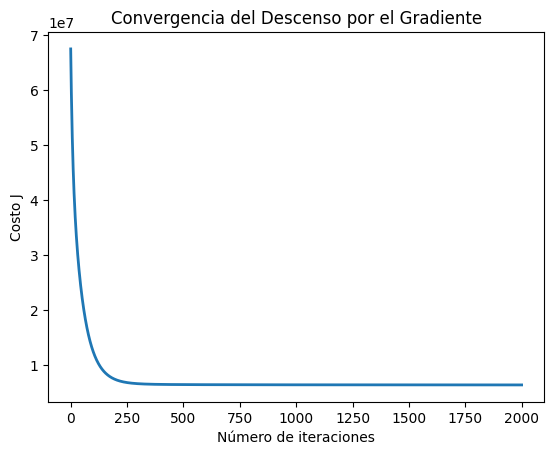

In [5]:
# Inicializamos theta con 33 ceros (32 columnas + la columna de unos)
theta = np.zeros(X_ready.shape[1])
# Parámetros: si el costo se dispara, baja alpha.
alpha = 0.01
num_iters = 2000

theta, J_historico = calcularDescensoGradiente(X_ready, y, theta, alpha, num_iters)

print(f"Theta calculado: {theta[:5]}...") # Imprime los primeros 5 para verificar
print(f"Costo final: {J_historico[-1]}")
# Graficar la convergencia
pyplot.plot(np.arange(len(J_historico)), J_historico, lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso por el Gradiente')

**VERIFICACION E INTEGRIDAD DE LOS DATOS**

aquí lo que estamos haciendo es una última auditoría de control para estar totalmente seguros de que no perdimos información en el camino y que todo está en orden comparamos el tamaño del archivo original con nuestra matriz final para confirmar que seguimos teniendo los treinta y cuatro mil trescientos seis registros completos y lo más importante es que hacemos un escaneo rápido buscando valores nulos porque si se nos hubiera escapado algún hueco o dato vacío el modelo matemático se rompería al intentar calcular los promedios así que al ver que el contador de nulos marca cero nos da la luz verde definitiva para confiar en que los datos están limpios y el entrenamiento es confiable

In [6]:
# Comprobación de integridad
print(f"Dimensiones del DataFrame original: {df.shape}")
print(f"Dimensiones de la matriz X (incluyendo todas las filas y columnas): {X.shape}")

# Ver si hay algún nulo que se nos escapó
print(f"¿Quedan valores nulos en X?: {np.isnan(X).sum()}")

Dimensiones del DataFrame original: (34306, 33)
Dimensiones de la matriz X (incluyendo todas las filas y columnas): (34306, 32)
¿Quedan valores nulos en X?: 0


**REALIDAD FRENTE A PREDICCION**

aquí llegamos a la prueba de donde ponemos a prueba el modelo calculando las predicciones finales con los pesos que aprendimos y las comparamos directamente con los costos reales de los accidentes en una gráfica de dispersión dibujamos una línea roja punteada que representa el escenario perfecto donde el modelo acertaría exactamente el precio y lo que buscamos es que todos esos puntos azules se agrupen lo más cerca posible de esa diagonal aunque vemos cierta dispersión debido a que los datos de salud son complejos y tienen variables naturales que no siempre siguen una regla matemática exacta la tendencia clara hacia la línea roja nos confirma que el modelo ha capturado la lógica de los costos y que es capaz de hacer estimaciones coherentes para el sistema hospitalario de bucaramanga

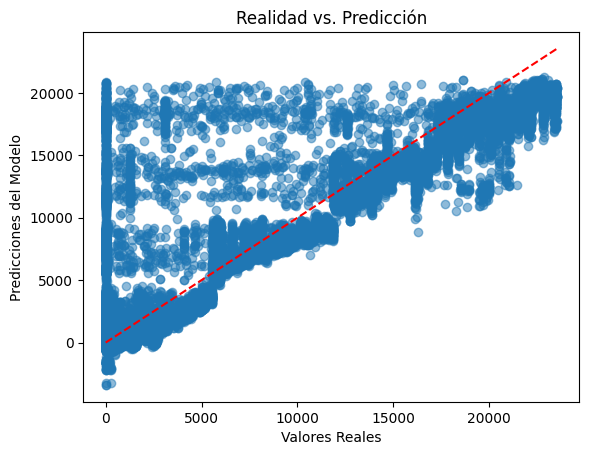

In [7]:
# --- GRÁFICA DE PREDICCIÓN VS REALIDAD ---
predicciones = np.dot(X_ready, theta)

pyplot.figure()
pyplot.scatter(y, predicciones, alpha=0.5)
pyplot.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Línea de referencia ideal
pyplot.xlabel('Valores Reales')
pyplot.ylabel('Predicciones del Modelo')
pyplot.title('Realidad vs. Predicción')
pyplot.show()



**Laboratorio 1: Regresión Lineal Multivariable**

**Estudiante: Juan De Dios Sullca Rodriguez**

**Materia: Inteligencia Artificial** I

**Dataset: Costos de atención hospitalaria en Bucaramanga (2018-2021)**

**Análisis del Modelo y Explicación**


En este laboratorio mi objetivo fue predecir los costos médicos de accidentes de tránsito implementando un modelo de Regresión Lineal Multivariable. Lo interesante de este dataset es que refleja datos del mundo real por lo que no estaba limpio y contenía texto además de valores faltantes. Antes de que el modelo pudiera aprender tuve que preparar los datos ya que los algoritmos solo entienden números. Para la traducción usé pd.factorize() transformando cada columna de texto en códigos numéricos y para la limpieza decidí llenar los espacios vacíos con el promedio de cada columna evitando así borrar filas y perder información valiosa de los pacientes.

Sobre la lógica matemática detrás del modelo implementé tres procesos clave. Primero apliqué una Normalización a los datos restando la media y dividiendo por la desviación estándar porque al tener variables con escalas tan distintas el algoritmo se habría vuelto inestable al calcular. Segundo utilicé la Función de Costo $J(\theta)$ que es mi forma de medir el error global comparando lo que el modelo predice contra los costos reales elevando la diferencia al cuadrado. Tercero apliqué el Descenso por el Gradiente que es el motor de aprendizaje ajustando los parámetros $\theta$ poco a poco en cada iteración usando una tasa de aprendizaje $\alpha$ de 0.01 para lograr un descenso suave y no saltarnos el punto óptimo.

Tras ejecutar 2000 iteraciones obtuve resultados muy interesantes que reflejan la realidad económica. En la gráfica de convergencia se ve cómo el costo baja de forma muy acelerada formando una curva limpia y se estabiliza. Como estamos calculando dinero real de facturas médicas el error no baja a casi cero como en ejercicios teóricos sino que se estabiliza en un valor propio de la escala financiera pero la forma en "L" invertida de la curva confirma que el entrenamiento fue un éxito.

La interpretación de la gráfica de Realidad vs Predicción es la parte más reveladora. Al graficar mis resultados contra los datos reales no obtuve una línea recta perfecta sino una dispersión de datos con agrupaciones verticales muy marcadas. Esto ocurre porque en la vida real dos accidentes idénticos en papel pueden tener costos diferentes y porque los hospitales manejan tarifas estándar o copagos fijos. A pesar de esta variabilidad natural la tendencia general de los puntos sigue la línea de referencia roja lo que me da la confianza de que el modelo logró capturar matemáticamente cómo las características del accidente impactan en la factura.

Como conclusión final este laboratorio me permitió ver que la preparación previa con Pandas y la normalización matemática son el verdadero secreto del éxito. Logré un modelo que no solo procesa números sino que entiende la tendencia real de los costos médicos demostrando que la regresión lineal es una herramienta robusta para analizar problemas complejos de salud pública.